# Paris PM2.5 trend: pooled and station fixed-effects estimates

Notebook 02 used FR04329 because it has observations in every year of the paper-comparison period. One traffic station cannot represent the whole monitoring network, so this notebook builds a panel of monthly means for all six Paris stations. Station fixed effects allow each station to have a different average concentration.

The main comparison uses two regressions on the same station-month observations. Both include a time trend and month-of-year effects; the pooled model does not control for station level, while the fixed-effects model does. Their difference measures how much the estimated trend changes after allowing for the changing mix of stations. This is a descriptive composition adjustment, not a separate estimate of a policy effect.

This diagnostic deliberately uses every Paris station with sufficient data because it studies monitoring-network composition. The later cross-city comparison uses four urban-background Paris stations and serves a different purpose; the two samples are not treated as interchangeable.

The window is 2013-2025. Valid negative hourly readings are retained because removing observations near the detection limit would truncate the lower tail and raise the calculated averages.

## References

**Estimation and inference**
- Panel-data and fixed-effects reference: Wooldridge, J.M. (2010).
  Econometric Analysis of Cross Section and Panel Data, 2nd edition.
  MIT Press.
  [Publisher record](https://mitpress.mit.edu/9780262232586/econometric-analysis-of-cross-section-and-panel-data/)
  | [QMUL Library e-book](https://www-vlebooks-com.ezproxy.library.qmul.ac.uk/Product/Index/997873?page=0&startBookmarkId=-1)
- Driscoll, J.C. and Kraay, A.C. (1998). Consistent covariance matrix estimation with spatially dependent panel data. Review of Economics and Statistics, 80(4), 549-560. [Public article record and DOI](https://doi.org/10.1162/003465398557825) | [QMUL Library article access](https://direct-mit-edu.ezproxy.library.qmul.ac.uk/rest/article/80/4/549/57104/Consistent-Covariance-Matrix-Estimation-with)
- Hoechle, D. (2007). Robust standard errors for panel regressions with cross-sectional dependence. Stata Journal 7(3), 281-312. [Open article copy](https://ageconsearch.umn.edu/record/119278/files/sjart_st0128.pdf). This provides an applied explanation for fixed effects and unbalanced panels.
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. Annals of Statistics 7, 1-26. [Article](https://doi.org/10.1214/aos/1176344552).
- Cameron, A.C., Gelbach, J.B. and Miller, D.L. (2008). Bootstrap-based improvements for inference with clustered errors. Review of Economics and Statistics 90, 414-427. [Accessible working-paper version](https://www.nber.org/papers/t0344).

**Data**
- Geod'Air, national air quality reference database (INERIS/LCSQA): validated hourly PM2.5, quality flag `validité == 1` as provided by the source. Six intra-muros Paris stations, window 2013 to 2025. [Database description](https://www.geodair.fr/a-propos).

**Data conventions**
- The station-month capture threshold adapts the EEA convention that PM2.5 stations have at least 75 percent valid data per calendar year. The EEA rule is annual; applying the same proportion to each month is a project choice for constructing reliable monthly means. [EEA indicator methodology](https://www.eea.europa.eu/en/analysis/indicators/exceedance-of-air-quality-standards).
- Negative valid readings are retained. Jiang, N., Akter, R., Ross, G., White, S., Kirkwood, J., Gunashanhar, G., Thompson, S., Riley, M. and Azzi, M. (2023). On thresholds for controlling negative particle (PM2.5) readings in air quality reporting. Environmental Monitoring and Assessment 195(10), 1187. [Open article](https://pmc.ncbi.nlm.nih.gov/articles/PMC10497433/). Negative values within instrument error are retained to avoid positive bias in averages.

**Code provenance**
- The fixed effects regression and Driscoll-Kraay covariance use `PanelOLS.fit(cov_type="kernel")` as documented by [`linearmodels`](https://bashtage.github.io/linearmodels/panel/panel/linearmodels.panel.model.PanelOLS.fit.html). The papers motivate the estimator; the package documentation is the source for the Python call.
- The calendar-year cluster bootstrap is written in this notebook. It samples the 13 calendar-year groups with replacement, applies the same sampled years to both regressions, and recalculates their difference. It uses NumPy with 2,000 draws and seed 42; the exact code is not taken from the cited papers.

**Software**
- linearmodels: Sheppard, K. linearmodels, estimation of linear panel models (Python package), used for PanelOLS with kernel (Driscoll-Kraay) covariance.
- statsmodels: Seabold, S. and Perktold, J. (2010). statsmodels: econometric and statistical modeling with Python. Proceedings of the 9th Python in Science Conference, 92-96.
- pandas: McKinney, W. (2010). Data structures for statistical computing in Python. Proceedings of the 9th Python in Science Conference, 56-61.
- numpy: Harris, C.R. et al. (2020). Array programming with NumPy. Nature 585, 357-362.
- scipy: Virtanen, P. et al. (2020). SciPy 1.0: fundamental algorithms for scientific computing in Python. Nature Methods 17, 261-272.
- matplotlib: Hunter, J.D. (2007). Matplotlib: a 2D graphics environment. Computing in Science and Engineering 9(3), 90-95.


## 1. Setup and the Geod'Air file reader

The same reader used in the validation notebook, included here so this notebook runs on its own.

In [1]:
import io
import os

import numpy as np
import pandas as pd

def load_geodair(path):
    """Read one of the quoted, semicolon-separated Geod'Air files."""
    with open(path, encoding='utf-8-sig') as f:
        raw = f.read()
    clean = []
    for ln in raw.splitlines():
        if not ln:
            continue
        if ln.startswith('"') and ln.endswith('"'):
            ln = ln[1:-1]
        clean.append(ln.replace('""', '"'))
    df = pd.read_csv(io.StringIO("\n".join(clean)), sep=';', quotechar='"', engine='python')
    df.columns = [c.strip().strip('"') for c in df.columns]
    return df

## 2. Load and clean the hourly data

I keep rows flagged as valid by Geod'Air and convert the concentration field to numeric form. Valid negative readings are retained because removing observations near the detection limit would truncate the lower tail and raise the calculated means.

The exports contain two date formats, so I parse each one explicitly and then check that every timestamp falls within 2013-2025.

In [2]:
def parse_geodair_dates(s):
    """Parse both date formats found in the yearly exports."""
    s = s.astype(str)
    out = pd.Series(pd.NaT, index=s.index, dtype="datetime64[ns]")
    slash = s.str.contains("/", na=False)
    out[slash]  = pd.to_datetime(s[slash],  format="%Y/%m/%d %H:%M:%S", errors="coerce")
    out[~slash] = pd.to_datetime(s[~slash], format="%Y-%m-%d %H:%M:%S", errors="coerce")
    assert out.notna().all(), f"{out.isna().sum()} timestamps failed to parse"
    return out

hourly_files = [
    f"Donnee_pm2.5_paris/Donnees_hourly_yearly/pm2.5_paris_{year}_hourly.csv"
    for year in range(2013, 2026)
]
missing_hourly = [path for path in hourly_files if not os.path.exists(path)]
assert not missing_hourly, f"Missing Geod'Air files: {missing_hourly}"
hourly = pd.concat([load_geodair(f) for f in hourly_files], ignore_index=True)

# Keep valid observations, including valid negative readings.
hourly = hourly[hourly["validité"] == 1].copy()
hourly["valeur brute"] = pd.to_numeric(hourly["valeur brute"], errors="coerce")
hourly = hourly.dropna(subset=["valeur brute"])
hourly["datetime"] = parse_geodair_dates(hourly["Date de début"])
assert hourly["datetime"].dt.year.between(2013, 2025).all(), "timestamp outside window"

print("Files:", len(hourly_files))
print("Rows:", len(hourly), "| negatives retained:", (hourly["valeur brute"] < 0).sum())
print("Stations:", sorted(hourly["code site"].unique()))
print("Years:", sorted(hourly["datetime"].dt.year.unique()))

Files: 13
Rows: 309901 | negatives retained: 690
Stations: ['FR04004', 'FR04031', 'FR04055', 'FR04131', 'FR04143', 'FR04329']
Years: [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025)]


## 3. Monthly mean per station, with a capture threshold

I average the hourly observations to one value per station per month. A station-month is retained when it contains at least 75 percent of the expected hours in that calendar month, implemented as `capture >= 0.75`. The EEA convention is defined for calendar years, so applying the same proportion month by month is a project choice rather than an official monthly rule. It prevents a small number of scattered observations from being treated as a reliable monthly mean.

The printed counts show that the panel is unbalanced: FR04329 contributes all 156 months, FR04143 ends in 2019, and several stations enter later. The regressions below test how much this changing coverage affects the estimated trend.

In [3]:
# Aggregate hourly observations to station-month means.
hourly["ym"] = hourly["datetime"].dt.to_period("M")

grp = hourly.groupby(["code site", "ym"])["valeur brute"].agg(["mean", "count"]).reset_index()
grp["expected"] = grp["ym"].apply(lambda p: p.days_in_month * 24)
grp["capture"] = grp["count"] / grp["expected"]

panel = grp[grp["capture"] >= 0.75].copy()
panel = panel.rename(columns={"mean": "pm25", "code site": "station"})

# Monthly means must be positive before taking logarithms.
assert (panel["pm25"] > 0).all(), "non-positive station-month mean after aggregation"

print("Station-months before capture filter:", len(grp))
print("Station-months after >=75% capture:", len(panel))
print("\nStation-months per station:")
print(panel.groupby("station").size())
print("\nCapture rate distribution:")
print(panel["capture"].describe().round(2))

Station-months before capture filter: 446
Station-months after >=75% capture: 431

Station-months per station:
station
FR04004     45
FR04031     35
FR04055     69
FR04131     48
FR04143     78
FR04329    156
dtype: int64

Capture rate distribution:
count    431.00
mean       0.97
std        0.04
min        0.77
25%        0.96
50%        0.99
75%        0.99
max        1.00
Name: capture, dtype: float64


## 4. Pooled versus station fixed-effects trends

The pooled and fixed-effects regressions use the same station-month observations, log concentration outcome, time trend and month-of-year controls. The pooled model does not allow stations to have different average levels, so lower-concentration stations entering later can make its decline appear steeper. The fixed-effects model adds a separate intercept for each station, making its trend a within-station estimate under the common-slope specification.

The fixed-effects standard error uses the Driscoll-Kraay covariance estimator. This allows for heteroskedasticity, serial dependence and correlation across stations, and is suitable here because the panel has many more months than stations. I use a Bartlett kernel with an 18-month bandwidth so the covariance can extend beyond one full seasonal cycle without giving weight to very distant months. The bandwidth is a modelling choice, not a value supplied by the original paper, so section 4a repeats the calculation at 6, 12, 18 and 24 months. I also report a conventional city series based on the arithmetic mean across reporting stations each month as a descriptive sensitivity check; it is not used to calculate the composition gap.

In [4]:
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf

# Prepare the station-month panel.
panel = panel.copy()
panel["log_pm25"] = np.log(panel["pm25"])
panel["date"] = panel["ym"].dt.to_timestamp()
panel["month_of_year"] = panel["date"].dt.month
# Continuous time in years, centred at January 2013.
panel["t"] = (panel["date"].dt.year - 2013) + (panel["date"].dt.month - 1) / 12

# Pooled model: no station effects.
pooled_model = smf.ols(
    "log_pm25 ~ t + C(month_of_year)", data=panel
).fit()
pooled_trend_pct = (np.exp(pooled_model.params["t"]) - 1) * 100

# Fixed-effects model: the same specification plus station intercepts.
fe_data = panel.set_index(["station", "date"])
mod_fe = PanelOLS.from_formula(
    "log_pm25 ~ 1 + t + C(month_of_year) + EntityEffects",
    data=fe_data,
    drop_absorbed=True,
)
res_fe = mod_fe.fit(
    cov_type="kernel", kernel="bartlett", bandwidth=18
)
fe_trend_pct = (np.exp(res_fe.params["t"]) - 1) * 100
composition_gap_pct = pooled_trend_pct - fe_trend_pct

# Descriptive check: log of the arithmetic monthly city mean.
city_monthly = (panel.groupby("date")
                .agg(pm25=("pm25", "mean"),
                     t=("t", "first"),
                     month_of_year=("month_of_year", "first"))
                .reset_index())
city_monthly["log_pm25"] = np.log(city_monthly["pm25"])
city_model = smf.ols(
    "log_pm25 ~ t + C(month_of_year)", data=city_monthly
).fit()
city_trend_pct = (np.exp(city_model.params["t"]) - 1) * 100

print("Pooled and fixed-effects comparison:\n")
print(f"Pooled trend:             {pooled_trend_pct:+.2f} %/yr")
print(f"Fixed-effects trend:      {fe_trend_pct:+.2f} %/yr")
print(f"Composition gap:          {composition_gap_pct:+.2f} pp/yr")
print(f"Fixed-effects log-slope SE (DK, 18 months): {res_fe.std_errors['t']:.4f}")
print(f"Arithmetic city-mean trend (descriptive):  {city_trend_pct:+.2f} %/yr")

Pooled and fixed-effects comparison:

Pooled trend:             -5.59 %/yr
Fixed-effects trend:      -4.78 %/yr
Composition gap:          -0.80 pp/yr
Fixed-effects log-slope SE (DK, 18 months): 0.0041
Arithmetic city-mean trend (descriptive):  -5.45 %/yr


## 4a. Driscoll-Kraay bandwidth sensitivity

The main fixed-effects estimate uses an 18-month bandwidth. I repeat the covariance calculation using 6, 12, 18 and 24 months. The fitted trend does not change; this check shows how much the standard error and confidence interval depend on the bandwidth. Each interval comes from the fitted `linearmodels` result through `conf_int()`, so it uses the package's debiased t reference rather than a manually fixed 1.96 multiplier.

In [5]:
bandwidth_rows = []
for bandwidth in [6, 12, 18, 24]:
    fit = mod_fe.fit(
        cov_type="kernel", kernel="bartlett", bandwidth=bandwidth
    )
    beta = fit.params["t"]
    se = fit.std_errors["t"]
    beta_interval = fit.conf_int().loc["t"]
    lower = (np.exp(beta_interval["lower"]) - 1) * 100
    upper = (np.exp(beta_interval["upper"]) - 1) * 100
    bandwidth_rows.append({
        "bandwidth_months": bandwidth,
        "trend_pct": (np.exp(beta) - 1) * 100,
        "se_log": se,
        "ci_lower_pct": lower,
        "ci_upper_pct": upper,
    })

bandwidth_check = pd.DataFrame(bandwidth_rows)
print(bandwidth_check.round(3).to_string(index=False))

 bandwidth_months  trend_pct  se_log  ci_lower_pct  ci_upper_pct
                6     -4.783   0.006        -5.931        -3.621
               12     -4.783   0.005        -5.758        -3.798
               18     -4.783   0.004        -5.542        -4.017
               24     -4.783   0.004        -5.524        -4.036


## 5. Uncertainty in the composition gap

The composition gap is the pooled trend minus the fixed-effects trend. Both regressions use the same outcome, observations and month-of-year controls, so the model difference is the addition of station intercepts. A negative gap means that the pooled decline is steeper before those station-level differences are controlled for.

The two estimates are based on the same observations and therefore are not independent. I use a non-parametric calendar-year cluster bootstrap: the 13 years are sampled with replacement and both models are refitted using the same draw. This keeps the stations and months from each sampled year together and preserves the pairing between the two estimates. The bootstrap uses explicit station indicators for the fixed effects; before resampling, an assertion checks that this produces the same composition gap as `PanelOLS`. It does not preserve dependence between adjacent years, and 13 year clusters is a small number, so the percentile interval is treated as a descriptive uncertainty check rather than strong evidence on its own. The calculation uses 2,000 draws and seed 42.

This interval describes uncertainty in the composition adjustment. It is not interpreted as the effect of any transport or environmental policy.

In [6]:
rng = np.random.default_rng(42)
years = np.sort(panel["date"].dt.year.unique())

def estimate_composition_gap(data):
    pooled_beta = smf.ols(
        "log_pm25 ~ t + C(month_of_year)", data=data
    ).fit().params["t"]
    fixed_effects_beta = smf.ols(
        "log_pm25 ~ t + C(month_of_year) + C(station)", data=data
    ).fit().params["t"]
    pooled_pct = (np.exp(pooled_beta) - 1) * 100
    fixed_effects_pct = (np.exp(fixed_effects_beta) - 1) * 100
    return pooled_pct - fixed_effects_pct

point_gap = estimate_composition_gap(panel)
assert np.isclose(point_gap, composition_gap_pct, atol=1e-8), (
    "Dummy-variable and PanelOLS fixed-effects estimates do not match"
)

gaps = []
for _ in range(2000):
    sampled = rng.choice(years, size=len(years), replace=True)
    boot = pd.concat(
        [panel[panel["date"].dt.year == year] for year in sampled],
        ignore_index=True)
    gaps.append(estimate_composition_gap(boot))
gaps = np.array(gaps)
gap_lower, gap_upper = np.percentile(gaps, [2.5, 97.5])

print("Calendar-year cluster bootstrap (2,000 draws, seed 42):\n")
print(f"Composition gap: {point_gap:+.2f} pp/yr")
print(f"95% interval: [{gap_lower:+.2f}, {gap_upper:+.2f}] pp/yr")
print("Interval excludes zero:", gap_lower > 0 or gap_upper < 0)

Calendar-year cluster bootstrap (2,000 draws, seed 42):

Composition gap: -0.80 pp/yr
95% interval: [-1.73, -0.05] pp/yr
Interval excludes zero: True


## 6. FR04329 and the two trend definitions

I first estimate the monthly log-linear trend for the traffic station FR04329, which contributes all 156 eligible months, with and without month-of-year controls. The seasonally adjusted result is then compared with the full fixed-effects panel. A difference can reflect genuine trend differences between station types as well as changing coverage, so this is a representativeness check rather than another estimate of the composition gap.

I then reconcile this notebook's proportional log-linear trend with the slope-to-starting-value ratio used for the paper comparison in notebook 02. The two percentages are not expected to be identical because they are different trend definitions.

Following notebook 02 section 10i, I construct a noiseless series declining at the fitted proportional rate and apply the ratio estimator on the same monthly grid. This isolates the definitional difference from sampling variation. The log-linear estimate remains the relevant measure for the panel analysis; the ratio result is shown only for comparison with Renard and Surcin.

In [7]:
from scipy import stats

# FR04329 under the same monthly log-linear definition.
one = panel[panel["station"] == "FR04329"].copy()
one_no_season = smf.ols("log_pm25 ~ t", data=one).fit()
one_with_season = smf.ols(
    "log_pm25 ~ t + C(month_of_year)", data=one
).fit()
one_trend_no_season = (np.exp(one_no_season.params["t"]) - 1) * 100
one_trend_seas = (np.exp(one_with_season.params["t"]) - 1) * 100

b, se = res_fe.params["t"], res_fe.std_errors["t"]
fe_pct = (np.exp(b) - 1) * 100
fe_beta_interval = res_fe.conf_int().loc["t"]
lo = (np.exp(fe_beta_interval["lower"]) - 1) * 100
hi = (np.exp(fe_beta_interval["upper"]) - 1) * 100

print(f"FR04329 monthly log-trend, no seasonal:   {one_trend_no_season:+.2f} %/yr")
print(f"FR04329 monthly log-trend, with seasonal: {one_trend_seas:+.2f} %/yr")
print(f"Full panel FE trend:                      {fe_pct:+.2f} %/yr  95% CI [{lo:+.2f}, {hi:+.2f}]")
print(f"Divergence, panel minus FR04329(seasonal): {fe_pct - one_trend_seas:+.2f} pp/yr")

# Reconcile the two trend definitions on the same monthly grid.
r = -np.log1p(fe_pct/100)
t_grid = np.sort(panel["t"].unique())
T = t_grid[-1] - t_grid[0]
pure = np.exp(-r * (t_grid - t_grid[0]))

res_pure = stats.linregress(t_grid, pure)
first_fitted = res_pure.intercept + res_pure.slope * t_grid[0]
exact_ratio = 100 * res_pure.slope / first_fitted
approx_ratio = -100 * (1 - np.exp(-r*T)) / T

print(f"\nDefinition reconciliation, r = {r:.4f}/yr over T = {T:.1f} years")
print(f"  log-linear rate                : {fe_pct:+.2f} %/yr")
print(f"  ratio form, exact on this grid : {exact_ratio:+.2f} %/yr")
print(f"  continuous approximation       : {approx_ratio:+.2f} %/yr   reference only")

FR04329 monthly log-trend, no seasonal:   -5.20 %/yr
FR04329 monthly log-trend, with seasonal: -5.12 %/yr
Full panel FE trend:                      -4.78 %/yr  95% CI [-5.54, -4.02]
Divergence, panel minus FR04329(seasonal): +0.34 pp/yr

Definition reconciliation, r = 0.0490/yr over T = 12.9 years
  log-linear rate                : -4.78 %/yr
  ratio form, exact on this grid : -3.70 %/yr
  continuous approximation       : -3.63 %/yr   reference only


### Figure. Paris PM2.5 pooled and fixed-effects trends

The grey points are the monthly geometric mean across the stations reporting in each month, calculated as `exp(mean(log PM2.5))`. This matches the outcome scale used by the regressions. The red line shows the pooled time trend and the blue line shows the station fixed-effects time trend.

For a direct visual comparison, both lines are anchored at the same average log concentration and the month effects are omitted from the plotted lines. Their vertical position is therefore illustrative; the reported slopes and the bootstrap interval come from the regression cells above.

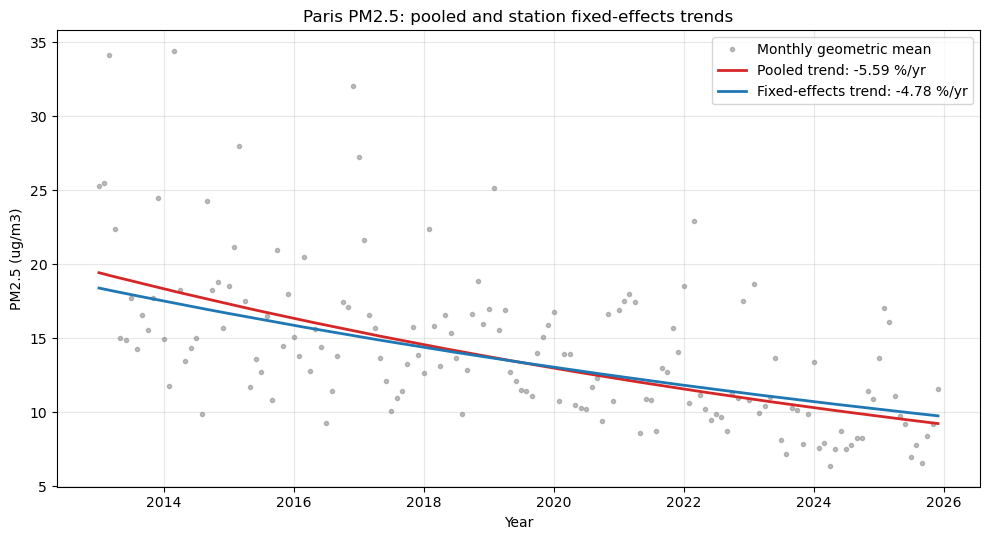

In [8]:
import matplotlib.pyplot as plt

# Monthly geometric mean and one time value per month.
plot_data = (panel.groupby("date")
             .agg(mean_log_pm25=("log_pm25", "mean"),
                  t=("t", "first"))
             .reset_index())
plot_data["geometric_pm25"] = np.exp(plot_data["mean_log_pm25"])

# Show only the estimated time component, with a shared reference level.
centre_t = plot_data["t"].mean()
anchor_log = plot_data["mean_log_pm25"].mean()
plot_data["pooled_line"] = np.exp(
    anchor_log + pooled_model.params["t"] * (plot_data["t"] - centre_t)
)
plot_data["fixed_effects_line"] = np.exp(
    anchor_log + res_fe.params["t"] * (plot_data["t"] - centre_t)
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(plot_data["date"], plot_data["geometric_pm25"], ".",
        color="grey", alpha=0.5, label="Monthly geometric mean")

ax.plot(plot_data["date"], plot_data["pooled_line"], "-",
        color="tab:red", linewidth=2,
        label=f"Pooled trend: {pooled_trend_pct:+.2f} %/yr")

ax.plot(plot_data["date"], plot_data["fixed_effects_line"], "-",
        color="tab:blue", linewidth=2,
        label=f"Fixed-effects trend: {fe_trend_pct:+.2f} %/yr")

ax.set_xlabel("Year")
ax.set_ylabel("PM2.5 (ug/m3)")
ax.set_title("Paris PM2.5: pooled and station fixed-effects trends")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()